In [1]:
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#load dataset 
df = pd.read_csv(r"C:\Users\Ghosts\Downloads\work_from_home_burnout_dataset.csv")
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [3]:
# Drop StudentID (not useful for prediction)
df = df.drop("user_id", axis=1)

In [4]:
# Drop StudentID (not useful for prediction)
df = df.drop("day_type", axis=1)

In [19]:
# Get statistical summary
summary = df.describe()
print(summary)

        work_hours  screen_time_hours  meetings_count  breaks_taken  \
count  1800.000000        1800.000000     1800.000000   1800.000000   
mean      6.515117           9.271406        1.941111      3.028889   
std       2.290521           2.409253        1.696178      1.417844   
min       3.000000           4.510000        0.000000      1.000000   
25%       4.430000           7.240000        1.000000      2.000000   
50%       6.445000           9.210000        2.000000      3.000000   
75%       8.510000          11.310000        3.000000      4.000000   
max      12.170000          15.700000       10.000000      5.000000   

       after_hours_work  sleep_hours  task_completion_rate  burnout_score  
count       1800.000000  1800.000000           1800.000000    1800.000000  
mean           0.358889     6.996467             72.308556      44.009978  
std            0.479808     1.061740             14.978647      23.881782  
min            0.000000     4.500000             40.0000

In [5]:
# Dataset shape
print("Shape:", df.shape)

# Data types
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

Shape: (1800, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   work_hours            1800 non-null   float64
 1   screen_time_hours     1800 non-null   float64
 2   meetings_count        1800 non-null   int64  
 3   breaks_taken          1800 non-null   int64  
 4   after_hours_work      1800 non-null   int64  
 5   sleep_hours           1800 non-null   float64
 6   task_completion_rate  1800 non-null   float64
 7   burnout_score         1800 non-null   float64
 8   burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(3), object(1)
memory usage: 126.7+ KB


work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

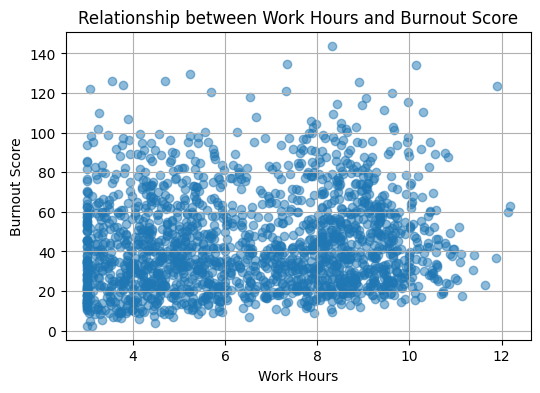

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(6,4))
plt.scatter(df["work_hours"], df["burnout_score"], alpha=0.5)
plt.xlabel("Work Hours")
plt.ylabel("Burnout Score")
plt.title("Relationship between Work Hours and Burnout Score")
plt.grid(True)
plt.show()

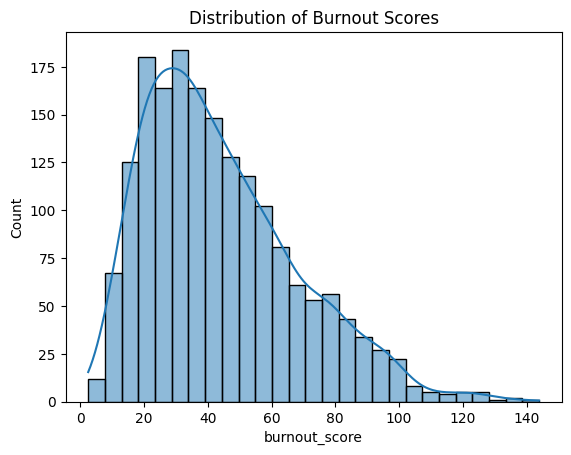

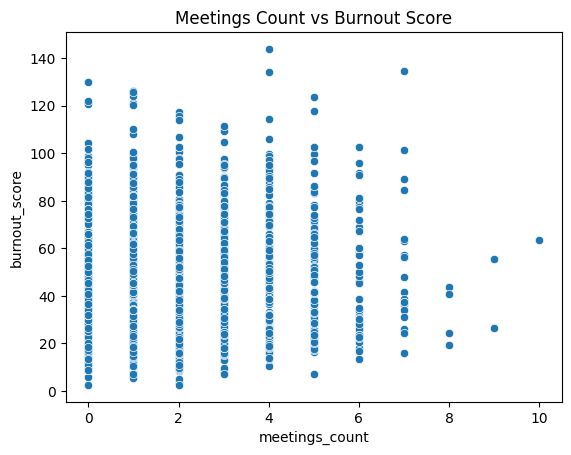

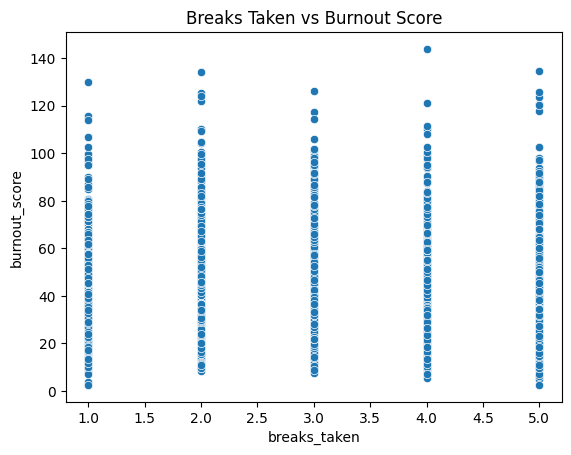

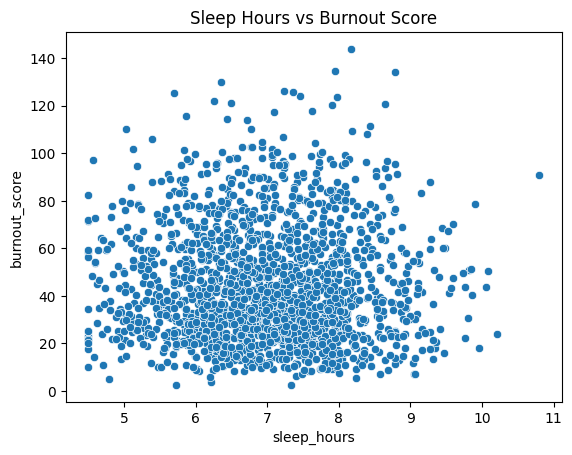

In [7]:
plt.figure()
sns.histplot(df["burnout_score"], kde=True)
plt.title("Distribution of Burnout Scores")
plt.show()

plt.figure()
sns.scatterplot(x="meetings_count", y="burnout_score", data=df)
plt.title("Meetings Count vs Burnout Score")
plt.show()

plt.figure()
sns.scatterplot(x="breaks_taken", y="burnout_score", data=df)
plt.title("Breaks Taken vs Burnout Score")
plt.show()

plt.figure()
sns.scatterplot(x="sleep_hours", y="burnout_score", data=df)
plt.title("Sleep Hours vs Burnout Score")
plt.show()

In [8]:
X = df.drop(columns=["burnout_score"])
y = df["burnout_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((1440, 8), (360, 8))

In [9]:
#performing numerical and categorical encoding 

categorical_cols = ["burnout_risk"]
numerical_cols = ["work_hours", "screen_time_hours", "meetings_count", 
                  "breaks_taken", "after_hours_work", "sleep_hours", "task_completion_rate"]

# 4. Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)



In [10]:
# 5. Create Pipeline
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

In [11]:
#fitting and Training Model

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [12]:
# Predictions
y_pred = model.predict(X_test)

In [13]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation (Rounded to 2 Decimal Places)")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Model Evaluation (Rounded to 2 Decimal Places)
MAE: 4.30
MSE: 29.41
RMSE: 5.42
R2 Score: 0.95


In [14]:
feature_names = model.named_steps["preprocessing"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print("\nCoefficient Table")
print(coef_df)


Coefficient Table
                     Feature  Coefficient
7     cat__burnout_risk_High    22.156771
1     num__screen_time_hours     0.582731
3          num__breaks_taken     0.103606
5           num__sleep_hours     0.035720
2        num__meetings_count    -0.113984
4      num__after_hours_work    -0.137911
0            num__work_hours    -0.443986
9   cat__burnout_risk_Medium    -7.251995
8      cat__burnout_risk_Low   -14.904776
6  num__task_completion_rate   -20.151110


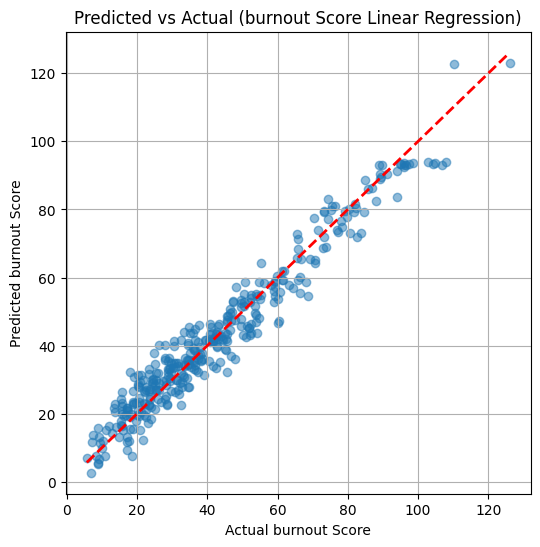

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual burnout Score")
plt.ylabel("Predicted burnout Score")
plt.title("Predicted vs Actual (burnout Score Linear Regression)")
plt.grid(True)
plt.show()

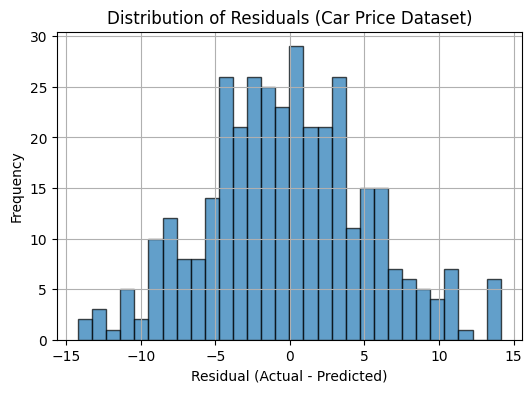

In [16]:
# Calculate residuals
residuals = y_test - y_pred

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (Car Price Dataset)")
plt.grid(True)
plt.show()

In [17]:
import pandas as pd

# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred 
})

# Display the first 10 rows (or all rows if you want)
print(results_df.head(10))

      Actual  Predicted
1591   17.98  15.395081
943    29.45  30.415155
869   106.94  92.958197
162    25.41  27.029992
1271   35.01  37.829356
70      9.10   6.787101
247    84.49  79.337244
322    45.12  43.604704
1659   58.93  52.774308
1004   23.90  22.134691


In [ ]:
# Create a DataFrame with actual and predict0

      Actual  Predicted  Residuals
1591   17.98      15.40       2.58
943    29.45      30.42      -0.97
869   106.94      92.96      13.98
162    25.41      27.03      -1.62
1271   35.01      37.83      -2.82
70      9.10       6.79       2.31
247    84.49      79.34       5.15
322    45.12      43.60       1.52
1659   58.93      52.77       6.16
1004   23.90      22.13       1.77
